<a href="https://colab.research.google.com/github/chandru1311/MLOPS-Tasks/blob/main/factory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Simple Linear Regression  

Coefficient (slope): 0.0117
Intercept         : 68.1537
Baseline MSE      : 109.8862


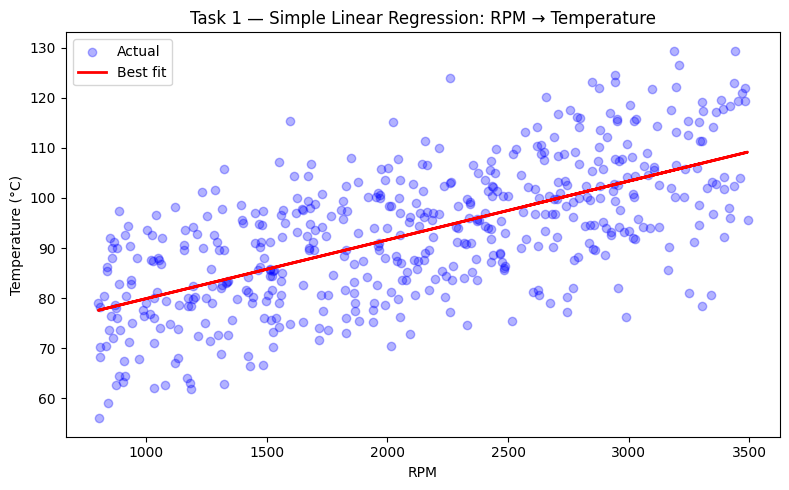

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv('factory_data.csv')

X = df[['RPM']]
y = df['Temperature']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
mse    = mean_squared_error(y, y_pred)
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept         : {model.intercept_:.4f}")
print(f"Baseline MSE      : {mse:.4f}")

plt.figure(figsize=(8, 5))
plt.title('Task 1 — Simple Linear Regression: RPM → Temperature')
plt.scatter(X, y, alpha=0.3, label='Actual', color='blue')
plt.plot(X, y_pred, color='red', linewidth=2, label='Best fit')
plt.xlabel('RPM')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

Task 2: Multivariable Regression  

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv('factory_data.csv')

X1 = df[['RPM']]
y  = df['Temperature']
m1 = LinearRegression().fit(X1, y)
mse1 = mean_squared_error(y, m1.predict(X1))

features = ['RPM', 'Vibration', 'Pressure']
X2 = df[features]
m2 = LinearRegression().fit(X2, y)
mse2 = mean_squared_error(y, m2.predict(X2))

# ── Compare ───────────────────────────────────────────
print(f"Task 1 MSE (1 feature)  : {mse1:.4f}")
print(f"Task 2 MSE (3 features) : {mse2:.4f}")
print(f"Improvement             : {mse1 - mse2:.4f}")
print("\nCoefficients:")
for name, coef in zip(features, m2.coef_):
    print(f"  {name:12s}: {coef:.4f}")

Task 1 MSE (1 feature)  : 109.8862
Task 2 MSE (3 features) : 61.2085
Improvement             : 48.6777

Coefficients:
  RPM         : 0.0120
  Vibration   : 2.0961
  Pressure    : 1.5135


Task 3: Save Model

In [ ]:
import pandas as pd
import joblib
from sklearn.linear_model import LinearRegression

df = pd.read_csv('factory_data.csv')
X  = df[['RPM', 'Vibration', 'Pressure']]
y  = df['Temperature']

model = LinearRegression().fit(X, y)

# Serialize ─────────────────────────────────────────
joblib.dump(model, 'temperature_model.pkl')
print("Model saved → temperature_model.pkl")

Model saved → temperature_model.pkl


Task 4: One-Hot Encoding

In [ ]:
import pandas as pd

df = pd.read_csv('factory_data.csv')

print("Before encoding:")
print(df['Machine_Mode'].value_counts())

# One-Hot Encode ─────────────────────────────────────
# drop_first=True drops 'Eco' → avoids Dummy Variable Trap
df_encoded = pd.get_dummies(
    df,
    columns=['Machine_Mode'],
    drop_first=True       # keeps Standard, High-Speed only
)

print("\nNew columns after encoding:")
print([c for c in df_encoded.columns if 'Machine_Mode' in c])
print(df_encoded.head(3))

# Save encoded dataset for Tasks 5 & 6
df_encoded.to_csv('factory_encoded.csv', index=False)
print("\nSaved → factory_encoded.csv")

Before encoding:
Machine_Mode
Eco           168
Standard      167
High-Speed    165
Name: count, dtype: int64

New columns after encoding:
['Machine_Mode_High-Speed', 'Machine_Mode_Standard']
    RPM  Vibration  Pressure  Voltage  Temperature  Defective  \
0  3289       5.87      6.06      244       115.12          1   
1  2431       6.79      5.24      216        93.87          0   
2  1815       4.53      5.89      236        95.81          0   

   Machine_Mode_High-Speed  Machine_Mode_Standard  
0                     True                  False  
1                    False                  False  
2                     True                  False  

Saved → factory_encoded.csv


Task 5: Train-Test Split  

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = pd.read_csv('factory_encoded.csv')  # from Task 4

feature_cols = ['RPM', 'Vibration', 'Pressure',
                'Voltage',
                'Machine_Mode_Standard',
                'Machine_Mode_High-Speed']
X = df[feature_cols]
y = df['Temperature']

# ── Split 80 / 20 ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train rows: {len(X_train)}  |  Test rows: {len(X_test)}")

# ── Train ONLY on training split ──────────────────────
model = LinearRegression().fit(X_train, y_train)

# ── Evaluate on UNSEEN test split ─────────────────────
y_pred_test  = model.predict(X_test)
y_pred_train = model.predict(X_train)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)

print(f"MSE on training set : {mse_train:.4f}  ← NEVER report this!")
print(f"MSE on test set     : {mse_test:.4f}  ← real performance")
print(f"Gap (overfit signal): {mse_test - mse_train:.4f}")

Train rows: 400  |  Test rows: 100
MSE on training set : 5.1989  ← NEVER report this!
MSE on test set     : 6.7668  ← real performance
Gap (overfit signal): 1.5679


Task 6: Logistic Regression

Accuracy: 0.8600

Classification Report:
              precision    recall  f1-score   support

        Good       0.89      0.94      0.91        77
   Defective       0.74      0.61      0.67        23

    accuracy                           0.86       100
   macro avg       0.81      0.77      0.79       100
weighted avg       0.85      0.86      0.86       100



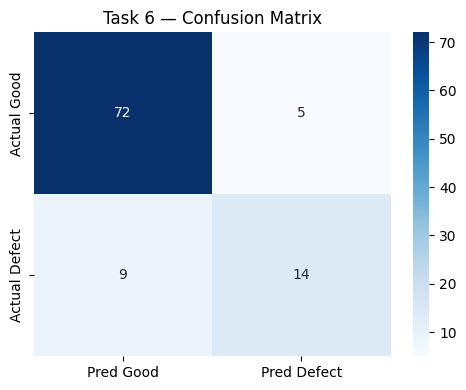

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix,
                               classification_report,
                               accuracy_score)

df = pd.read_csv('factory_encoded.csv')

feature_cols = ['RPM', 'Vibration', 'Pressure',
                'Voltage',
                'Machine_Mode_Standard',
                'Machine_Mode_High-Speed']
X = df[feature_cols]
y = df['Defective']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Train Logistic Regression ──────────────────────────
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# ── Metrics ────────────────────────────────────────────
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Good', 'Defective']))

# ── Confusion Matrix ───────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Good','Pred Defect'],
            yticklabels=['Actual Good','Actual Defect'])
plt.title('Task 6 — Confusion Matrix')
plt.tight_layout()
plt.show()